In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

def get_global_scaling_params(image_stack, clip_percentile=0.1):
    """
    Compute consistent min and max values across a stack of images using percentiles.
    """
    flat = image_stack.astype(np.float32).ravel()
    vmin = np.percentile(flat, clip_percentile)
    vmax = np.percentile(flat, 100 - clip_percentile)
    return vmin, vmax

def colorise(im, color, min_val=None, max_val=None):
    if im.ndim > 2 and im.shape[2] != 1:
        raise ValueError('This function expects a single-channel image!')

    im = im.astype(np.float32)

    if min_val is None:
        min_val = np.min(im)
    if max_val is None:
        max_val = np.max(im)

    im_scaled = (im - min_val) / (max_val - min_val + 1e-8)
    im_scaled = np.clip(im_scaled, 0, 1)

    im_scaled = np.atleast_3d(im_scaled)
    color = np.asarray(color).reshape((1, 1, -1))
    return im_scaled * color

3
250


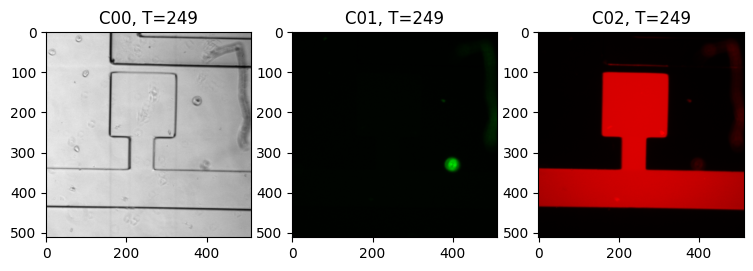

[np.float64(534.6664657592773), np.float64(522.0271339416504), np.float64(490.1633644104004), np.float64(485.6435737609863), np.float64(485.5796585083008), np.float64(481.7597427368164), np.float64(483.98140716552734), np.float64(482.71925354003906), np.float64(479.4536895751953), np.float64(476.82112884521484), np.float64(473.2521667480469), np.float64(473.651912689209), np.float64(474.6500473022461), np.float64(474.26464080810547), np.float64(477.5723571777344), np.float64(477.302303314209), np.float64(472.64687728881836), np.float64(474.38997650146484), np.float64(476.27283096313477), np.float64(474.4824447631836), np.float64(1605.000831604004), np.float64(3309.4662017822266), np.float64(2599.210159301758), np.float64(2639.5631408691406), np.float64(3365.9377784729004), np.float64(3051.2020683288574), np.float64(2937.074146270752), np.float64(3383.3147888183594), np.float64(3162.103645324707), np.float64(3001.054973602295), np.float64(3337.564697265625), np.float64(3171.741027832031

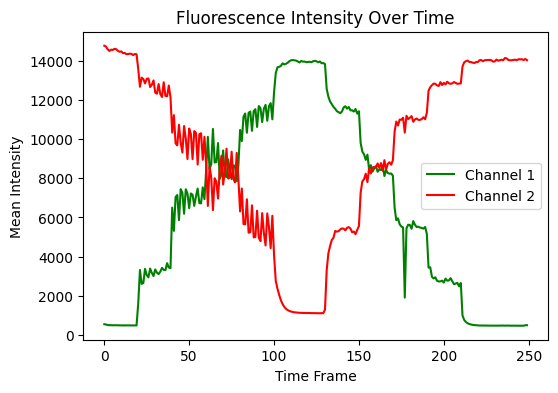

In [ ]:
import os
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Define parameters
num_timepoints = 250
channels = ['C00', 'C01', 'C02']
image_prefix = "/content/Position001--t"
file_extension = ".tif"

def load_images():
    images = {ch: [] for ch in channels}
    intensity_ch01 = []
    intensity_ch02 = []

    for t in range(num_timepoints):
          time_str = f"{t:02d}"
          for ch in channels:

            filename = f"{image_prefix}{time_str}--{ch}{file_extension}"#{ch}{file_extension}"#
            if os.path.exists(filename):
                img = iio.imread(filename)
                images[ch].append(img)

                if ch == 'C01':
                    intensity_ch01.append(np.mean(img))
                elif ch == 'C02':
                    intensity_ch02.append(np.mean(img))
            else:
                print(f"Warning: File {filename} not found!")



    return images, intensity_ch01, intensity_ch02


# Load images and intensity values
images, intensity_ch01, intensity_ch02 = load_images()
print(len(images))
print(len(intensity_ch02))
# Normalise intensity values
def normalise_intensity(intensity_values):
    min_val = min(intensity_values)
    max_val = max(intensity_values)
    return [(val - min_val) / (max_val - min_val) for val in intensity_values],min_val,max_val

normalised_intensity_ch01,min_valc1,max_valc1 = normalise_intensity(intensity_ch01)
normalised_intensity_ch02,min_valc2,max_valc2 = normalise_intensity(intensity_ch02)


def create_video():
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    ims = []

    for t in range(len(intensity_ch01)):

        imset = []
        for i, ch in enumerate(channels):
            if ch == 'C01':
                im = axes[i].imshow(colorise(images[ch][t], color=[0, 1, 0]),animated=True)  # Green for ch01
            elif ch == 'C02':
                im = axes[i].imshow(colorise(images[ch][t], color=[1, 0, 0]), animated= True)  # Red for ch02
            else:
                im = axes[i].imshow(images[ch][t], cmap='gray', animated=True)  # Grayscale for ch00
            imset.append(im)
            title = axes[i].set_title(f"{ch}, T={t}")
            imset.append(title)
            #axes[i].axis('off')

        ims.append(imset)

    ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True)
     # Save the video
    ani.save("fluorescence_video.mp4", writer="ffmpeg")
    plt.show()

create_video()
print(intensity_ch01)
print(intensity_ch02)
def plot_intensity():
    plt.figure(figsize=(6, 4))
    plt.plot(range(num_timepoints),intensity_ch01, label='Channel 1', color='green')
    plt.plot(range(num_timepoints),intensity_ch02, label='Channel 2', color='red')

    plt.xlabel('Time Frame')
    plt.ylabel('Mean Intensity')
    plt.title('Fluorescence Intensity Over Time')
    plt.legend()
    plt.show()

plot_intensity()

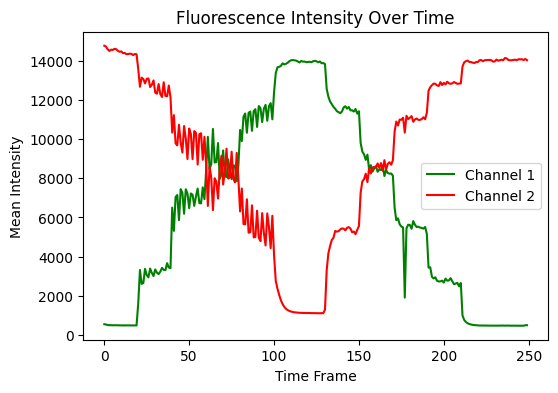

In [ ]:

def plot_intensity():
    plt.figure(figsize=(6, 4))
    plt.plot(range(num_timepoints),intensity_ch01, label='Channel 1', color='green')
    plt.plot(range(num_timepoints),intensity_ch02, label='Channel 2', color='red')

    plt.xlabel('Time Frame')
    plt.ylabel('Mean Intensity')
    plt.title('Fluorescence Intensity Over Time')
    plt.legend()
    plt.show()

plot_intensity()

In [ ]:
duty_cycles = [100,80, 60,40, 20,0,20, 40,60,80,100]
time_intervals = [20,20,20,20,20,30,20,20,20,20,40]

def generate_vectors(duty_cycles, time_intervals, length=250):
    vector1 = []
    vector2 = []

    for i, (dc, interval) in enumerate(zip(duty_cycles, time_intervals)):
        vector1.extend([dc] * interval)
        vector2.extend([dc] * interval)

 # Reverse mapping

    return np.array(vector1[:length]), np.array(vector2[:length])

vector1, vector2 = generate_vectors(duty_cycles, time_intervals)
print(vector1)

vector2=np.abs(vector2-100).tolist()
print(vector2)

def plot_intensity():
    plt.figure(figsize=(6, 4))
    #plt.plot(range(num_timepoints),normalised_intensity_ch01, label='Channel 1', color='green')
    #plt.plot(range(num_timepoints), normalised_intensity_ch02, label='Channel 2', color='red')
    plt.plot(range(num_timepoints), vector1, label='Duty Cycle 1', linestyle='--', color='green',alpha=0.5)
    plt.plot(range(num_timepoints), vector2, label='Duty Cycle 2', linestyle='--', color='red',alpha=0.5)
    plt.plot(range(num_timepoints),intensity_ch01, label='Channel 1', color='green')
    plt.plot(range(num_timepoints), intensity_ch02, label='Channel 2', color='red')
    plt.xlabel('Time Frame')
    plt.ylabel('Mean Intensity')
    plt.title('Fluorescence Intensity Over Time')
    plt.legend()
    plt.show()

[100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100  80  80  80  80  80  80  80  80  80  80  80  80  80  80  80  80
  80  80  80  80  60  60  60  60  60  60  60  60  60  60  60  60  60  60
  60  60  60  60  60  60  40  40  40  40  40  40  40  40  40  40  40  40
  40  40  40  40  40  40  40  40  20  20  20  20  20  20  20  20  20  20
  20  20  20  20  20  20  20  20  20  20   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0  20  20  20  20  20  20  20  20  20  20  20  20  20  20
  20  20  20  20  20  20  40  40  40  40  40  40  40  40  40  40  40  40
  40  40  40  40  40  40  40  40  60  60  60  60  60  60  60  60  60  60
  60  60  60  60  60  60  60  60  60  60  80  80  80  80  80  80  80  80
  80  80  80  80  80  80  80  80  80  80  80  80 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 10

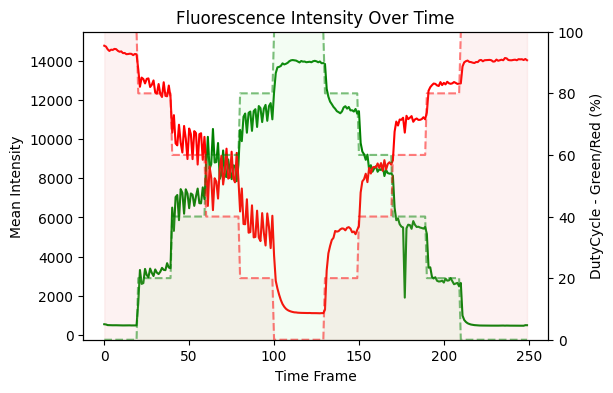

In [ ]:
def plot_intensity():
    fig, ax1 = plt.subplots(figsize=(6, 4))

    # Primary y-axis for normalised intensity
    ax1.set_xlabel('Time Frame')
    ax1.set_ylabel('Mean Intensity', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.plot(range(num_timepoints),intensity_ch01, label='Channel 1', color='green')
    ax1.plot(range(num_timepoints), intensity_ch02, label='Channel 2', color='red')

    # Secondary y-axis for duty cycles
    ax2 = ax1.twinx()
    ax2.set_ylabel('DutyCycle - Green/Red (%)', color='black')
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis='y', labelcolor='black')

    # Plot duty cycles on the secondary axis
    ax2.plot(range(len(vector2)), vector2, label='Green', linestyle='--', color='green', alpha=0.5)
    ax2.plot(range(len(vector1)), vector1, label='Red', linestyle='--', color='red', alpha=0.5)
    ax2.fill_between(range(len(vector2)), vector2, color='lightgreen', alpha=0.1)
    ax2.fill_between(range(len(vector1)), vector1, color='lightcoral', alpha=0.1)

    # Add legends
    #fig.legend(loc='upper right')
    plt.title('Fluorescence Intensity Over Time')
    plt.show()

plot_intensity()


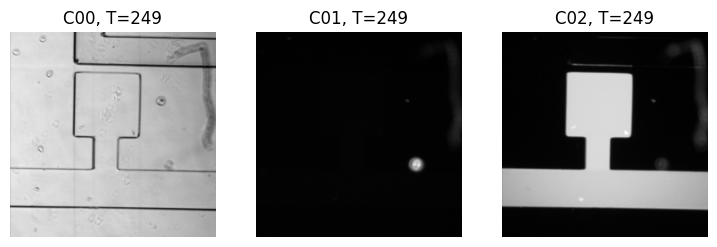

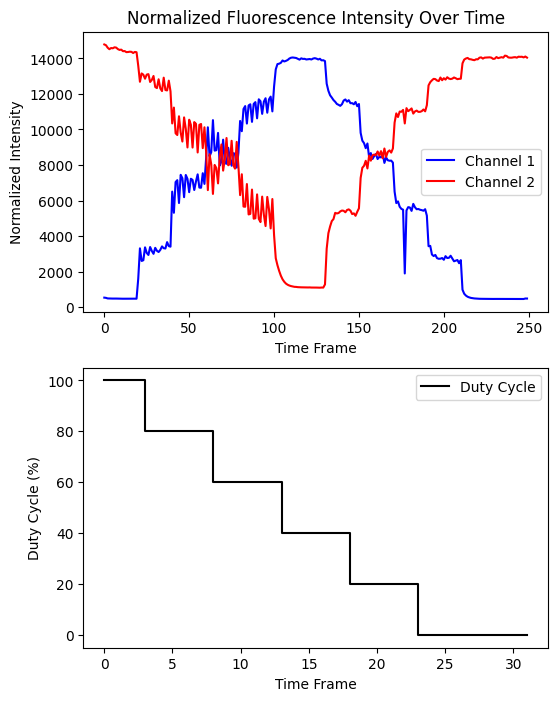

In [ ]:
# Define duty cycle values and time intervals
duty_cycles = [100, 80, 60, 40, 20, 0]
time_intervals = [3, 5, 5, 5, 5, 8]
time_points = np.cumsum([0] + time_intervals)

def create_video():
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    ims = []

    for t in range(num_timepoints):
        imset = []
        for i, ch in enumerate(channels):
           # if ch == 'C01':
           #     im = axes[i].imshow(colorise(images[ch][t], color=[0, 1, 0]),animated=True)  # Green for ch01
           # elif ch == 'C02':
           #     im = axes[i].imshow(colorise(images[ch][t], color=[1, 0, 0]), animated= True)  # Red for ch02
           # else:
            im = axes[i].imshow(images[ch][t], cmap='gray', animated=True)  # Grayscale for ch00
            #im = axes[i].imshow(images[ch][t], cmap='gray', animated=True)
            axes[i].set_title(f"{ch}, T={t}")
            axes[i].axis('off')
            imset.append(im)
        ims.append(imset)

    ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True)

    # Save the video
    ani.save("fluorescence_video.mp4", writer="ffmpeg")
    plt.show()

create_video()

def animate_plot(i, ax1, ax2, line1, line2, line3):
    ax1.clear()
    ax2.clear()

    ax1.plot(range(i+1), intensity_ch01[:i+1], label='Channel 1', color='blue')
    ax1.plot(range(i+1), intensity_ch02[:i+1], label='Channel 2', color='red')
    ax1.set_xlabel('Time Frame')
    ax1.set_ylabel('Normalised Intensity')
    ax1.set_title('Normalised Fluorescence Intensity Over Time')
    ax1.legend()

    ax2.step(time_points, duty_cycles + [duty_cycles[-1]], where='post', color='black', label='Duty Cycle')
    ax2.set_xlabel('Time Frame')
    ax2.set_ylabel('Duty Cycle (%)')
   # ax2.set_title('Duty Cycle Over Time')
    ax2.legend()

def plot_intensity_dynamic():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

    ani = animation.FuncAnimation(fig, animate_plot, frames=num_timepoints, fargs=(ax1, ax2, None, None, None), interval=200)
    ani.save("intensity_plot.mp4", writer="ffmpeg")
    plt.show()

plot_intensity_dynamic()